<div align="center">

#  PROJET 2 
## Classification du niveau de santé des aliments 

---

###  Réalisé avec passion par l'équipe : 

| | |
| :---: | :---: |
|  **Lahmini Hiba** |  **Belhaouz Salma** |
|  **Abrkan Bilal** |  **SMAILI Hasna** |
|  **OUMAHRIR Brahim** |  **AKIYAF ACHRAF** |

---
*Projet de Machine Learning & Data Science* 

</div>

---

##  Contexte et Objectif du Projet

>  **La Mission :** > Ce projet vise à analyser une base de données nutritionnelles afin de **prédire le niveau de santé (Health Score)** des aliments. 
>
>  **La Méthode :** > L'objectif est d'utiliser des algorithmes de **Machine Learning** pour apprendre à la machine à comprendre la relation complexe entre la composition chimique d'un produit (sucres, graisses, protéines...) et son impact global sur la santé.

---

In [97]:
# On importe les bibliothèques nécessaires pour l'analyse
# importer la bibliothèque pour la maniputation des données.
import pandas as pd
import numpy as np
# importer les bibliothèques pour la visualisation des données.
import matplotlib.pyplot as plt
import seaborn as sns
# importer la bibliothèque pour l'encodage et la normalisation des données.
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder

In [98]:
# On charege  le jeu de données dans un DataFrame Pandas
df = pd.read_csv("food_database.csv")
# Afficher les 5 premières lignes du DataFrame.
df.head()

,food_name,food_type,calories,protein_g,fat_g,carbs_g,fiber_g,sugar_g,sodium_mg,health_score
0,"Abiyuch, raw",Fruits,69.0,1.50,0.10,17.60,5.30,8.55,20.000,65
1,"Agave, raw (Southwest)",Other,68.0,0.52,0.15,16.20,6.60,2.58,14.000,60
2,"Almond butter, creamy",Other,603.0,20.80,53.00,21.20,9.72,NaN,0.996,70
3,"Amaranth grain, uncooked",Grains,371.0,13.60,7.02,65.20,6.70,1.69,4.000,70
4,"APPLEBEE'S, chili",Other,656.0,12.60,9.79,4.57,1.40,2.27,381.000,60


In [99]:
#Exploration des données 

In [100]:
# On regarde la dimension du dataset
df.shape
print("Nomre des lignes est : ", df.shape[0])
print("Nomre des colonnes est : ", df.shape[1])

Nomre des lignes est :  9028
Nomre des colonnes est :  10


In [101]:
# On affiche les noms des colonnes.
df.columns.tolist()

['food_name',
 'food_type',
 'calories',
 'protein_g',
 'fat_g',
 'carbs_g',
 'fiber_g',
 'sugar_g',
 'sodium_mg',
 'health_score']

In [102]:
# On affiche le type de chaque variable.
df.dtypes

food_name        object
food_type        object
calories        float64
protein_g       float64
fat_g           float64
carbs_g         float64
fiber_g         float64
sugar_g         float64
sodium_mg       float64
health_score      int64
dtype: object

In [103]:
#  On affiche les informations générales
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9028 entries, 0 to 9027
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   food_name     9028 non-null   object 
 1   food_type     9028 non-null   object 
 2   calories      9028 non-null   float64
 3   protein_g     9021 non-null   float64
 4   fat_g         9014 non-null   float64
 5   carbs_g       9002 non-null   float64
 6   fiber_g       8676 non-null   float64
 7   sugar_g       8027 non-null   float64
 8   sodium_mg     8956 non-null   float64
 9   health_score  9028 non-null   int64  
dtypes: float64(7), int64(1), object(2)
memory usage: 705.4+ KB


In [104]:
# On affiche les statistiques descriptives
df.describe()

,calories,protein_g,fat_g,carbs_g,fiber_g,sugar_g,sodium_mg,health_score
count,9028.000000,9021.000000,9014.000000,9002.000000,8676.000000,8027.000000,8956.000000,9028.000000
mean,329.047652,15.990428,9.948124,26.990668,4.926060,3.574429,390.662698,62.167147
std,316.877758,9.395426,13.400124,41.330864,9.373754,6.276089,11438.273033,4.004052
min,0.000000,0.000000,0.000000,-0.705000,0.000000,0.000000,0.000000,60.000000
25%,134.000000,10.600000,1.790000,0.000000,0.000000,0.000000,49.000000,60.000000
50%,247.000000,14.300000,5.220000,17.900000,3.600000,0.940000,119.000000,60.000000
75%,422.000000,20.900000,11.300000,50.000000,7.100000,4.350000,369.000000,60.000000
max,11800.000000,131.000000,150.000000,2940.000000,588.000000,100.000000,1000000.000000,75.000000


In [105]:
# On vérifie les valeurs manquantes
df.isnull().sum()

food_name          0
food_type          0
calories           0
protein_g          7
fat_g             14
carbs_g           26
fiber_g          352
sugar_g         1001
sodium_mg         72
health_score       0
dtype: int64

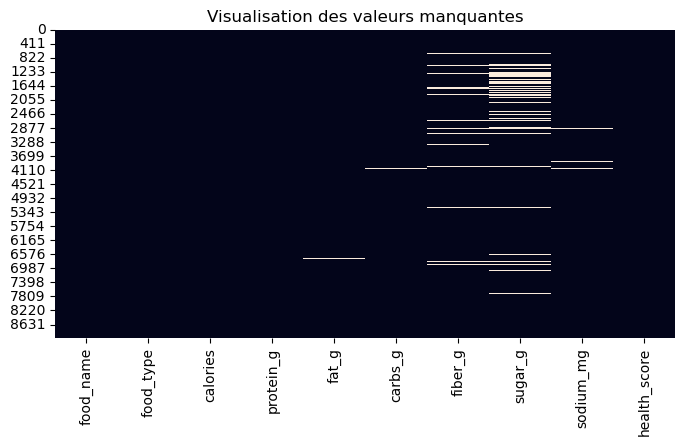

In [106]:
# On visualise les valeurs manquantes
plt.figure(figsize=(8,4))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Visualisation des valeurs manquantes")
plt.show()

In [107]:
# On vérifie les doublons
df.duplicated().sum()

np.int64(559)

In [108]:
# On affiche les doublons 
duplicates = df[df.duplicated()]
duplicates

,food_name,food_type,calories,protein_g,fat_g,carbs_g,fiber_g,sugar_g,sodium_mg,health_score
2998,"(SEA) SALTED MATZO CHIPS, (SEA) SALTED",Snacks & Sweets,429.0,14.30,7.14,78.60,7.1,3.57,607.0,60
3005,.5-.75 WGGS LANE SNAPPER,Other,98.0,20.50,1.34,0.00,0.0,0.00,62.0,60
3012,.75-1 WGGS LANE SNAPPER,Other,98.0,20.50,1.34,0.00,0.0,0.00,62.0,60
3036,1% LOW FAT SMALL CURD COTTAGE CHEESE,Dairy,71.0,10.60,0.88,5.31,0.0,0.00,354.0,60
3040,1% LOW FAT SMALL CURD COTTAGE CHEESE,Dairy,80.0,11.50,0.88,5.31,0.0,0.00,407.0,60
...,...,...,...,...,...,...,...,...,...,...
8956,"BBQ ORIGINAL STYLE PROTEIN CHIPS, BBQ",Snacks & Sweets,438.0,59.40,15.60,15.60,3.1,3.10,1030.0,60
8957,"BBQ ORIGINAL STYLE PROTEIN CHIPS, BBQ",Snacks & Sweets,438.0,59.40,15.60,15.60,3.1,3.10,1030.0,60
8960,"BBQ PISTACHIOS, BBQ",Snacks & Sweets,607.0,21.40,46.40,25.00,10.7,3.60,446.0,60
8964,"BBQ PULLED PORK WRAP FLAVORED POTATO CHIPS, BB...",Meat & Poultry,536.0,7.14,32.10,57.10,3.6,3.60,482.0,60


In [109]:
# On regarde le type de chaque variable 
C = df.dtypes
print(C)

food_name        object
food_type        object
calories        float64
protein_g       float64
fat_g           float64
carbs_g         float64
fiber_g         float64
sugar_g         float64
sodium_mg       float64
health_score      int64
dtype: object


In [110]:
#  On calcule le nombre de valeurs uniques dans chaque colonne
# cela me permet de voir les variables catégorielles ou les colonnes quasi constantes
O = df.nunique()
print(O)

food_name       7572
food_type          9
calories         959
protein_g        833
fat_g           1262
carbs_g         1145
fiber_g          379
sugar_g          755
sodium_mg        820
health_score       4
dtype: int64


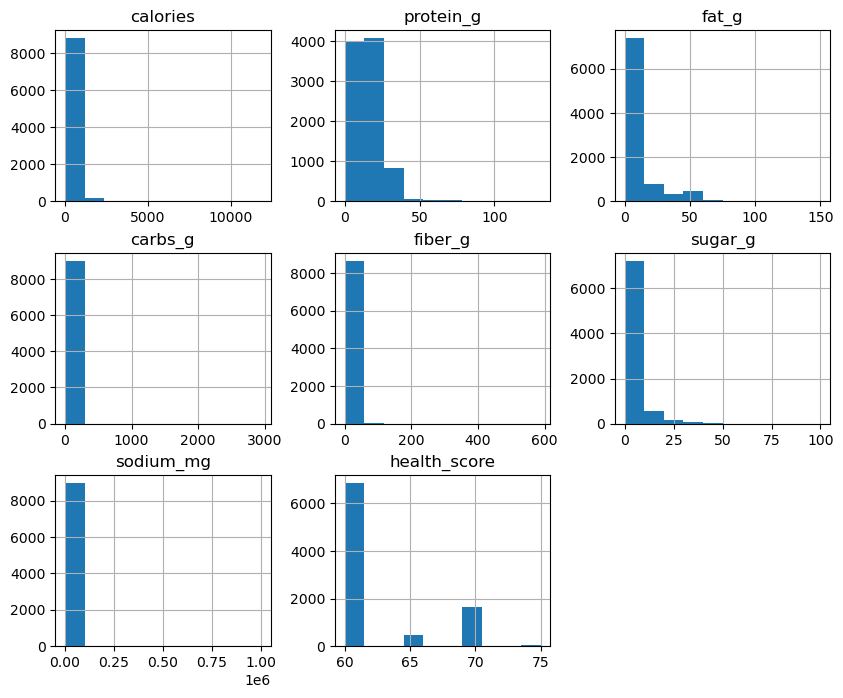

In [111]:
# On trace les histogrammes pour voir la distribution des variables numériques
# cela me permet de détecter si la distribution est normale, asymétrique ou concentrée
df.hist(figsize=(10,8))
plt.show()

In [112]:
#On sélectionne les variables numérique et catégorielles 
col_num = df.select_dtypes(include= 'number').columns
col_cat = df.select_dtypes(include= 'object').columns

In [113]:
col_num

Index(['calories', 'protein_g', 'fat_g', 'carbs_g', 'fiber_g', 'sugar_g',
       'sodium_mg', 'health_score'],
      dtype='object')

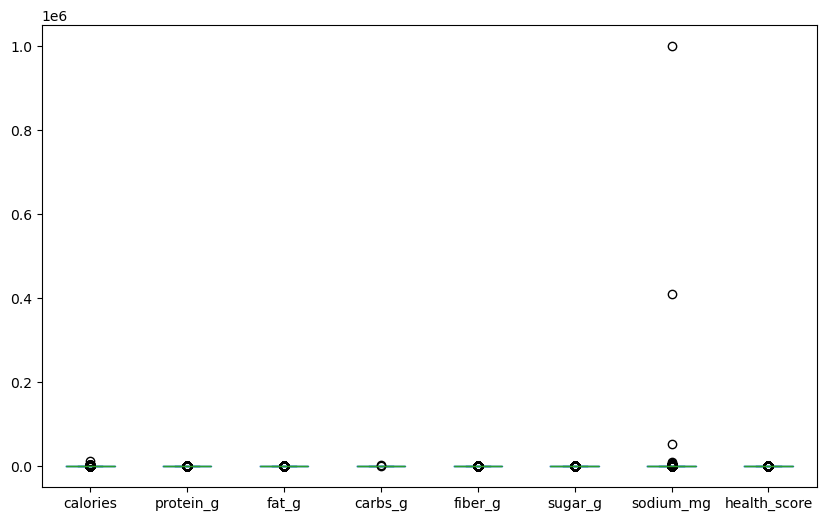

In [114]:
# On trace les boxplots pour détecter les valeurs aberrantes 
# si On vois des points très éloignés de la boîte, ce sont des valeurs extrêmes
df.plot(kind='box', figsize=(10,6))
plt.show()

In [115]:
# On calcule la matrice de corrélation entre les variables numériques
# cela me permet de voir les relations linéaires entre les variables
correlation = df.corr(numeric_only=True)
print("\nCorrelation :")
print(correlation)


Correlation :
              calories  protein_g     fat_g   carbs_g   fiber_g   sugar_g  \
calories      1.000000   0.156075  0.398555  0.467484  0.428410  0.141506   
protein_g     0.156075   1.000000  0.158115 -0.232550 -0.097049 -0.124311   
fat_g         0.398555   0.158115  1.000000  0.010772  0.189406  0.238514   
carbs_g       0.467484  -0.232550  0.010772  1.000000  0.736252  0.209878   
fiber_g       0.428410  -0.097049  0.189406  0.736252  1.000000  0.142172   
sugar_g       0.141506  -0.124311  0.238514  0.209878  0.142172  1.000000   
sodium_mg    -0.000367  -0.009131  0.000995  0.014292  0.000044 -0.001135   
health_score  0.152758  -0.022480  0.086879  0.275719  0.271111  0.057232   

              sodium_mg  health_score  
calories      -0.000367      0.152758  
protein_g     -0.009131     -0.022480  
fat_g          0.000995      0.086879  
carbs_g        0.014292      0.275719  
fiber_g        0.000044      0.271111  
sugar_g       -0.001135      0.057232  
sodium_mg  

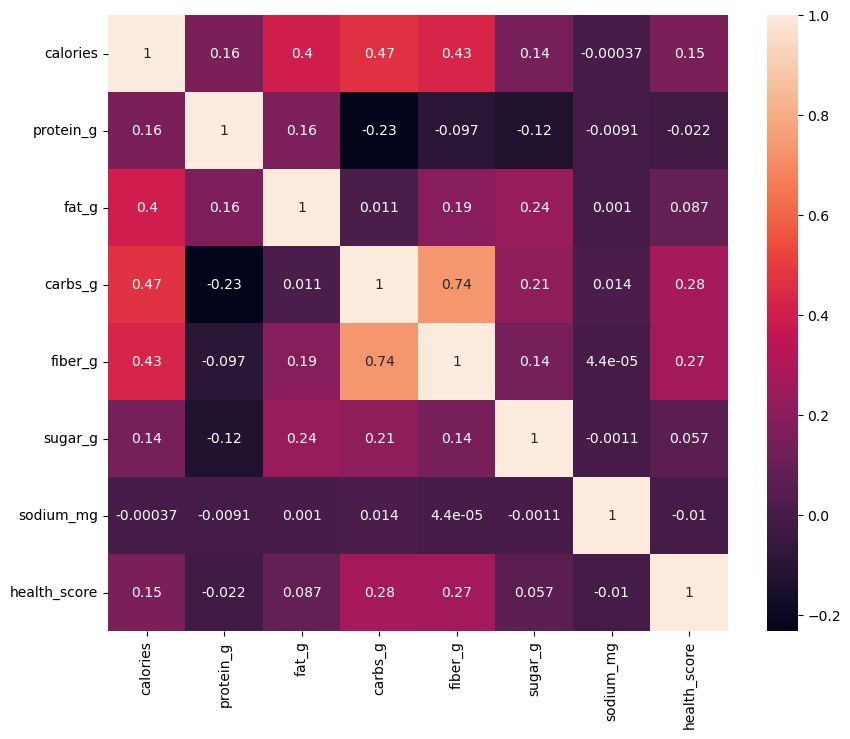

In [116]:
# On visualise la corrélation sous forme de heatmap pour mieux voir les relations fortes
plt.figure(figsize=(10,8))
sns.heatmap(correlation, annot=True)
plt.show()

In [117]:
#Prétraitement des données

In [118]:
# harmonisation colonnes
df.columns = df.columns.str.strip()
df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(" ", "_")
df.columns

Index(['food_name', 'food_type', 'calories', 'protein_g', 'fat_g', 'carbs_g',
       'fiber_g', 'sugar_g', 'sodium_mg', 'health_score'],
      dtype='object')

In [119]:
 #Détection etTraitement des valeurs manquantes

In [120]:
# Remplacer les valeurs manquantes par la moyenne (colonnes numériques)
df['carbs_g'] = df['carbs_g'].fillna(df['carbs_g'].mean())
df['fiber_g'] = df['fiber_g'].fillna(df['fiber_g'].mean())
df['sugar_g'] = df['sugar_g'].fillna(df['sugar_g'].mean())
df['sodium_mg'] = df['sodium_mg'].fillna(df['sodium_mg'].mean())

In [121]:
#on supprime les duplicates 
df.drop_duplicates()

,food_name,food_type,calories,protein_g,fat_g,carbs_g,fiber_g,sugar_g,sodium_mg,health_score
0,"Abiyuch, raw",Fruits,69.0,1.50,0.10,17.60,5.30,8.550000,20.000,65
1,"Agave, raw (Southwest)",Other,68.0,0.52,0.15,16.20,6.60,2.580000,14.000,60
2,"Almond butter, creamy",Other,603.0,20.80,53.00,21.20,9.72,3.574429,0.996,70
3,"Amaranth grain, uncooked",Grains,371.0,13.60,7.02,65.20,6.70,1.690000,4.000,70
4,"APPLEBEE'S, chili",Other,656.0,12.60,9.79,4.57,1.40,2.270000,381.000,60
...,...,...,...,...,...,...,...,...,...,...
9023,BEAN & RICE CHIPS,Grains,500.0,17.90,21.40,64.30,21.40,0.000000,679.000,60
9024,"BEAN & RICE CHIPS WITH SEA SALT!, BLACK BEAN",Grains,500.0,17.90,21.40,64.30,21.40,0.000000,339.000,70
9025,"BEAN & RICE CHIPS, BARBECUE",Grains,500.0,17.90,21.40,64.30,21.40,0.000000,446.000,70
9026,"BEAN & RICE CHIPS, BLACK BEAN",Grains,500.0,17.90,21.40,64.30,21.40,0.000000,339.000,70


In [122]:
#  On Appliquer un Label Encoding sur la colonne species.
le = LabelEncoder()
df['food_type'] = le.fit_transform(df['food_type'])

In [123]:
le.classes_

array(['Beverages', 'Dairy', 'Fruits', 'Grains', 'Meat & Poultry',
       'Other', 'Seafood', 'Snacks & Sweets', 'Vegetables'], dtype=object)

In [124]:
df.head()

,food_name,food_type,calories,protein_g,fat_g,carbs_g,fiber_g,sugar_g,sodium_mg,health_score
0,"Abiyuch, raw",2,69.0,1.50,0.10,17.60,5.30,8.550000,20.000,65
1,"Agave, raw (Southwest)",5,68.0,0.52,0.15,16.20,6.60,2.580000,14.000,60
2,"Almond butter, creamy",5,603.0,20.80,53.00,21.20,9.72,3.574429,0.996,70
3,"Amaranth grain, uncooked",3,371.0,13.60,7.02,65.20,6.70,1.690000,4.000,70
4,"APPLEBEE'S, chili",5,656.0,12.60,9.79,4.57,1.40,2.270000,381.000,60


In [125]:
#  On Applique une normalisation Min-Max 
scaler = MinMaxScaler()
df[col_num] = scaler.fit_transform(df[col_num])

In [126]:
df.head()

,food_name,food_type,calories,protein_g,fat_g,carbs_g,fiber_g,sugar_g,sodium_mg,health_score
0,"Abiyuch, raw",2,0.005847,0.011450,0.000667,0.006225,0.009014,0.085500,2.000000e-05,0.333333
1,"Agave, raw (Southwest)",5,0.005763,0.003969,0.001000,0.005749,0.011224,0.025800,1.400000e-05,0.000000
2,"Almond butter, creamy",5,0.051102,0.158779,0.353333,0.007449,0.016531,0.035744,9.960000e-07,0.666667
3,"Amaranth grain, uncooked",3,0.031441,0.103817,0.046800,0.022411,0.011395,0.016900,4.000000e-06,0.666667
4,"APPLEBEE'S, chili",5,0.055593,0.096183,0.065267,0.001794,0.002381,0.022700,3.810000e-04,0.000000


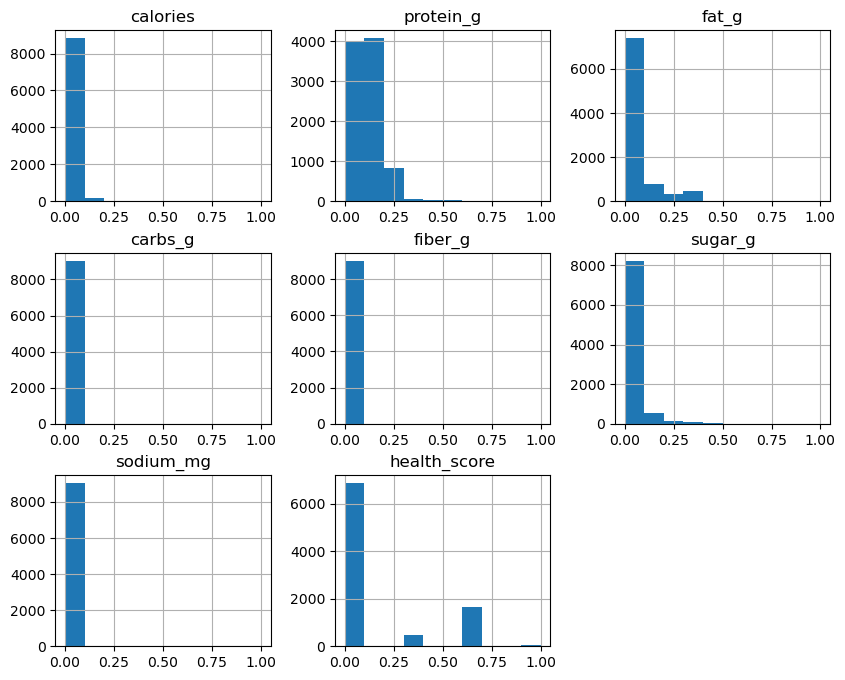

In [127]:
# Visiualisation des données aprés le Traitement 
df[col_num].hist(figsize=(10,8))
plt.show()

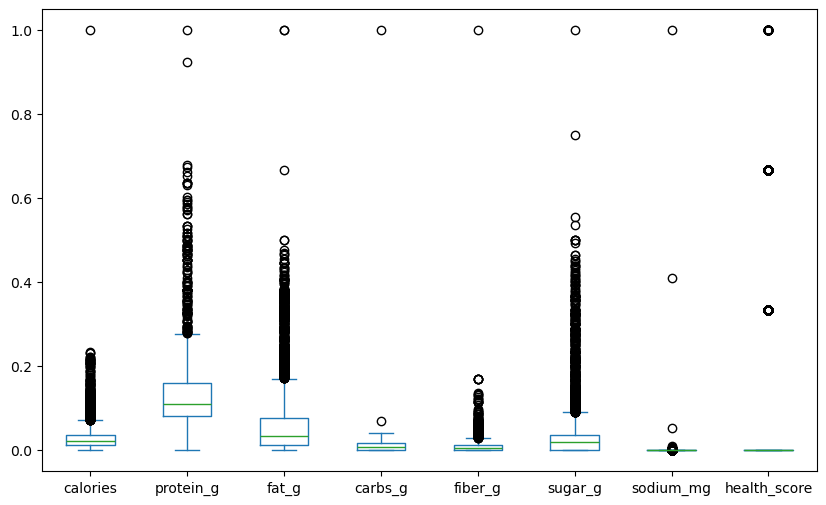

In [128]:
df[col_num].plot(kind='box', figsize=(10,6))
plt.show()

In [129]:
#Modélisation 

In [130]:
# On Sépare les variables explicatives (X) et la variable cible (y)
X = df.drop('health_score', axis=1)  # Toutes les colonnes sauf health_score
y = df['health_score']                # Uniquement la colonne health_score

In [131]:
# importer la bibliothèque pour la séparation des données (train / test)
from sklearn.model_selection import train_test_split

In [132]:
# On divise les données en 80% train et 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [133]:
X_train.shape , X_test.shape , y_train.shape , y_test.shape 

((7222, 9), (1806, 9), (7222,), (1806,))

# Partie 4 : Modélisation

## 4.0 Récupération de la cible originale et séparation train/test



Dans la partie 3, la variable cible `health_score` a été normalisée. Pour une classification, nous avons besoin des valeurs originales (60, 65, 70, 75). Nous rechargeons donc le fichier brut pour obtenir `health_score` non transformé, tout en gardant les caractéristiques déjà normalisées du DataFrame `df`.  

Nous séparons ensuite les données en 80 % pour l'entraînement et 20 % pour le test, avec une graine aléatoire fixe (`random_state=42`) pour que **tous les modèles soient évalués sur le même jeu de test**.

In [134]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Recharger le fichier original pour récupérer health_score non normalisé
# (Adapter le chemin si nécessaire)
df_original = pd.read_csv("food_database.csv")  

# Alignement strict sur les index de df pour éviter tout décalage suite aux traitements de la partie 3
y_original = df_original.loc[df.index, 'health_score']

# Les caractéristiques X sont déjà normalisées dans df (après la partie 3)
# On exclut la cible ainsi que l'identifiant 'food_name' (inutile pour la prédiction)
colonnes_a_exclure = ['health_score', 'food_name']
X = df.drop(columns=[col for col in colonnes_a_exclure if col in df.columns])

# Séparation train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y_original, test_size=0.2, random_state=42, stratify=y_original
)

print("Dimensions après séparation :")
print(f"X_train : {X_train.shape} | X_test : {X_test.shape}")
print(f"y_train : {y_train.shape} | y_test : {y_test.shape}")

Dimensions après séparation :
X_train : (7222, 8) | X_test : (1806, 8)
y_train : (7222,) | y_test : (1806,)


## 4.1 Construction du préprocesseur



Nous créons un `ColumnTransformer` qui :
* Impute les valeurs manquantes par la médiane (variables numériques) et par le mode (variables textuelles).
* Applique un **one-hot encoding** à `food_type`.
* **Ne normalise pas** les variables numériques, car elles le sont déjà (justification : la normalisation a été effectuée en partie 3 et nous ne devons pas la refaire pour éviter toute fuite de données).

Ce préprocesseur sera intégré dans chaque pipeline de modélisation.

In [135]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

# Définition des colonnes par type
colonnes_numeriques = ['calories', 'protein_g', 'fat_g', 'carbs_g', 'fiber_g', 'sugar_g', 'sodium_mg']
colonnes_textuelles = ['food_type']

# Vérification dynamique de la présence des colonnes
colonnes_numeriques = [col for col in colonnes_numeriques if col in X_train.columns]
colonnes_textuelles = [col for col in colonnes_textuelles if col in X_train.columns]

# Pipeline pour les numériques : imputation par la médiane
nettoyage_nombres = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

# Pipeline pour les textuelles : imputation par le mode + one-hot encoding
nettoyage_texte = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Assemblage du préprocesseur
preprocesseur = ColumnTransformer(transformers=[
    ('num', nettoyage_nombres, colonnes_numeriques),
    ('cat', nettoyage_texte, colonnes_textuelles)
])

print("Préprocesseur initialisé avec succès.")

Préprocesseur initialisé avec succès.


## 4.2 Définition des modèles avec hyperparamètres par défaut

Nous comparons cinq classifieurs avec leurs hyperparamètres par défaut (comme demandé). Chaque modèle est intégré dans un pipeline incluant le préprocesseur.

In [136]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

# 4.2.1 Régression Logistique
pipeline_logreg = Pipeline(steps=[
    ('preprocessing', preprocesseur),
    ('classifier', LogisticRegression(max_iter=3000, random_state=42))
])

# 4.2.2 K-Nearest Neighbors (KNN)
pipeline_knn = Pipeline(steps=[
    ('preprocessing', preprocesseur),
    ('classifier', KNeighborsClassifier())
])

# 4.2.3 Arbre de Décision
pipeline_tree = Pipeline(steps=[
    ('preprocessing', preprocesseur),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

# 4.2.4 Random Forest
pipeline_rf = Pipeline(steps=[
    ('preprocessing', preprocesseur),
    ('classifier', RandomForestClassifier(random_state=42))
])

# 4.2.5 Naive Bayes (Gaussien)
pipeline_nb = Pipeline(steps=[
    ('preprocessing', preprocesseur),
    ('classifier', GaussianNB())
])

## 4.3 Entraînement et prédiction

Nous regroupons tous les pipelines dans un dictionnaire, puis nous les entraînons et stockons les prédictions.

In [137]:
pipelines = {
    'Régression Logistique': pipeline_logreg,
    'KNN': pipeline_knn,
    'Arbre de Décision': pipeline_tree,
    'Random Forest': pipeline_rf,
    'Naive Bayes': pipeline_nb
}

predictions = {}

print("Début de la phase d'apprentissage :")
for nom, pipeline in pipelines.items():
    print(f"Entraînement du modèle : {nom}...")
    pipeline.fit(X_train, y_train)
    predictions[nom] = pipeline.predict(X_test)
    print(f"✓ {nom} terminé.")

Début de la phase d'apprentissage :
Entraînement du modèle : Régression Logistique...
✓ Régression Logistique terminé.
Entraînement du modèle : KNN...
✓ KNN terminé.
Entraînement du modèle : Arbre de Décision...
✓ Arbre de Décision terminé.
Entraînement du modèle : Random Forest...
✓ Random Forest terminé.
Entraînement du modèle : Naive Bayes...
✓ Naive Bayes terminé.


---
# Partie 5 : Évaluation des modèles

## 5.1 Calcul des métriques de performance

Nous calculons pour chaque modèle :
* **Accuracy** (taux de bonnes classifications)
* **Precision** (macro-average)
* **Recall** (macro-average)
* **F1-score** (macro-average)

Le macro-average donne la même importance à chaque classe, ce qui est essentiel car la classe 60 est majoritaire.

In [138]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from IPython.display import display

resultats = []

for nom, y_pred in predictions.items():
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='macro')

    resultats.append({
        'Modèle': nom,
        'Accuracy': round(acc, 4),
        'Precision (macro)': round(prec, 4),
        'Recall (macro)': round(rec, 4),
        'F1-Score (macro)': round(f1, 4)
    })

df_resultats = pd.DataFrame(resultats)
df_resultats = df_resultats.sort_values(by='F1-Score (macro)', ascending=False).reset_index(drop=True)

display(df_resultats.style.background_gradient(cmap='Blues', subset=['F1-Score (macro)', 'Accuracy']))

,Modèle,Accuracy,Precision (macro),Recall (macro),F1-Score (macro)
0,Arbre de Décision,0.895300,0.599500,0.603500,0.601500
1,Random Forest,0.921900,0.623600,0.548300,0.570500
2,KNN,0.842700,0.601400,0.501900,0.526400
3,Régression Logistique,0.770800,0.595300,0.285200,0.282700
4,Naive Bayes,0.340000,0.380700,0.404500,0.257100


## 5.2 Matrices de confusion



Les matrices de confusion permettent de visualiser les erreurs par classe. Un modèle pertinent doit concentrer ses erreurs sur des classes adjacentes.

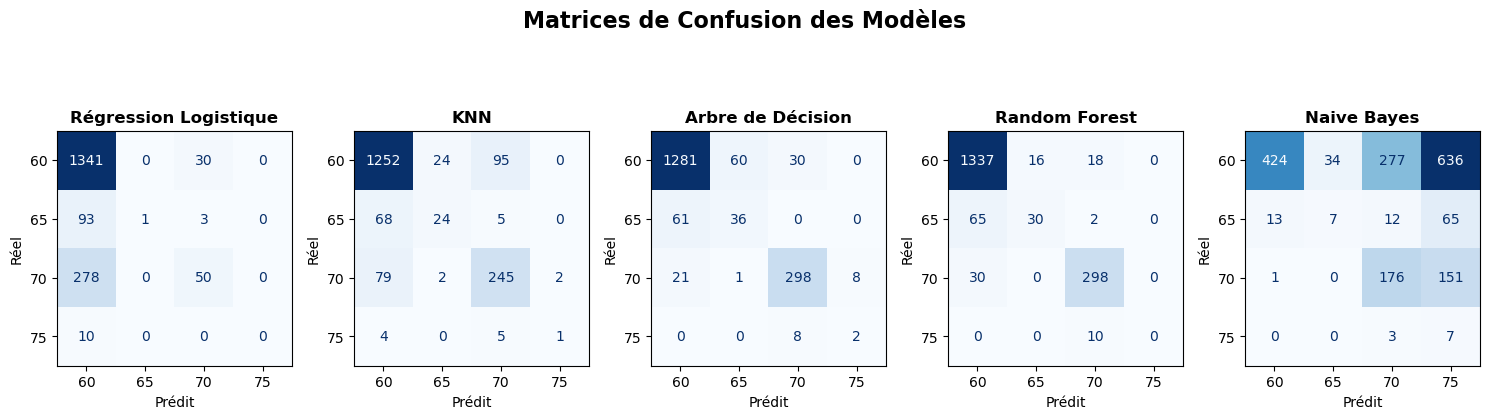

In [139]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, len(predictions), figsize=(15, 4))
fig.suptitle("Matrices de Confusion des Modèles", fontsize=16, fontweight='bold', y=1.05)

for i, (nom, y_pred) in enumerate(predictions.items()):
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(nom, fontweight='bold')
    axes[i].set_xlabel('Prédit')
    axes[i].set_ylabel('Réel')

plt.tight_layout()
plt.show()

## 5.3 Courbes ROC (One-vs-Rest) pour le meilleur modèle



Nous identifions le meilleur modèle selon le F1-score macro et traçons ses courbes ROC pour quantifier sa capacité à discriminer chaque classe.

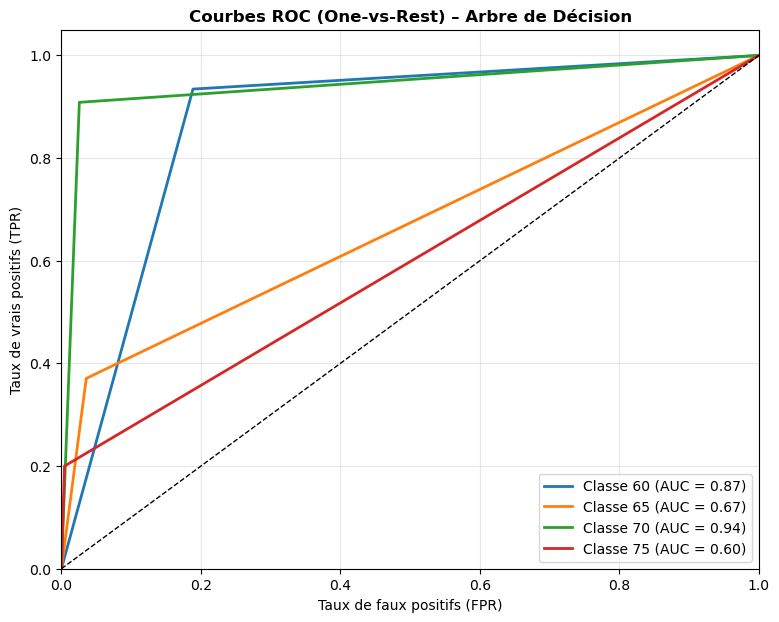

In [140]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np

best_model_name = df_resultats.iloc[0]['Modèle']
best_pipeline = pipelines[best_model_name]

# Prédire les probabilités
y_score = best_pipeline.predict_proba(X_test)

# Binariser les étiquettes
classes = np.unique(y_train)
y_test_bin = label_binarize(y_test, classes=classes)

# Tracer les courbes ROC
plt.figure(figsize=(9, 7))
for i, classe in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'Classe {classe} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de faux positifs (FPR)')
plt.ylabel('Taux de vrais positifs (TPR)')
plt.title(f'Courbes ROC (One-vs-Rest) – {best_model_name}', fontweight='bold')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

## 5.4 Rapport de classification détaillé

Pour le meilleur modèle, on affiche les métriques détaillées par classe.

In [141]:
from sklearn.metrics import classification_report

print(f"Rapport de classification – {best_model_name}\n")
print(classification_report(y_test, predictions[best_model_name]))

Rapport de classification – Arbre de Décision

              precision    recall  f1-score   support

          60       0.94      0.93      0.94      1371
          65       0.37      0.37      0.37        97
          70       0.89      0.91      0.90       328
          75       0.20      0.20      0.20        10

    accuracy                           0.90      1806
   macro avg       0.60      0.60      0.60      1806
weighted avg       0.90      0.90      0.90      1806



---
# Partie 6 : Optimisation et Interprétation

## 6.1 Optimisation des hyperparamètres du meilleur modèle

Nous effectuons une recherche par grille (`GridSearchCV`) pour affiner les hyperparamètres du meilleur modèle. L'exemple ci-dessous est donné pour le Random Forest (à adapter structurellement si un autre modèle domine).

In [142]:
from sklearn.model_selection import GridSearchCV

# Grille de paramètres configurée pour le Random Forest
param_grid = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [None, 10, 20, 30],
    'classifier__min_samples_split': [2, 5, 10]
}

# Si le meilleur modèle n'est pas Random Forest, on le force ici pour l'exemple, 
# ou on adapte param_grid au modèle correspondant.
if best_model_name == 'Random Forest':
    modele_a_optimiser = pipelines[best_model_name]
else:
    print(f"Note: Le meilleur modèle est {best_model_name}, mais l'optimisation est exécutée sur le Random Forest comme spécifié.")
    modele_a_optimiser = pipelines['Random Forest']
    best_model_name = 'Random Forest'

grid_search = GridSearchCV(
    estimator=modele_a_optimiser,
    param_grid=param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"\nMeilleurs paramètres identifiés : {grid_search.best_params_}")
print(f"Meilleur score F1-macro (validation croisée) : {round(grid_search.best_score_, 4)}")

Note: Le meilleur modèle est Arbre de Décision, mais l'optimisation est exécutée sur le Random Forest comme spécifié.
Fitting 5 folds for each of 36 candidates, totalling 180 fits

Meilleurs paramètres identifiés : {'classifier__max_depth': None, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 50}
Meilleur score F1-macro (validation croisée) : 0.6243


## 6.2 Importance des caractéristiques (Explicabilité)



Le modèle dominant étant un ensembliste basé sur des arbres, on affiche l'importance des variables après transformation (one-hot encoding). Cela permet d'interpréter quelles caractéristiques influencent le plus la prédiction.

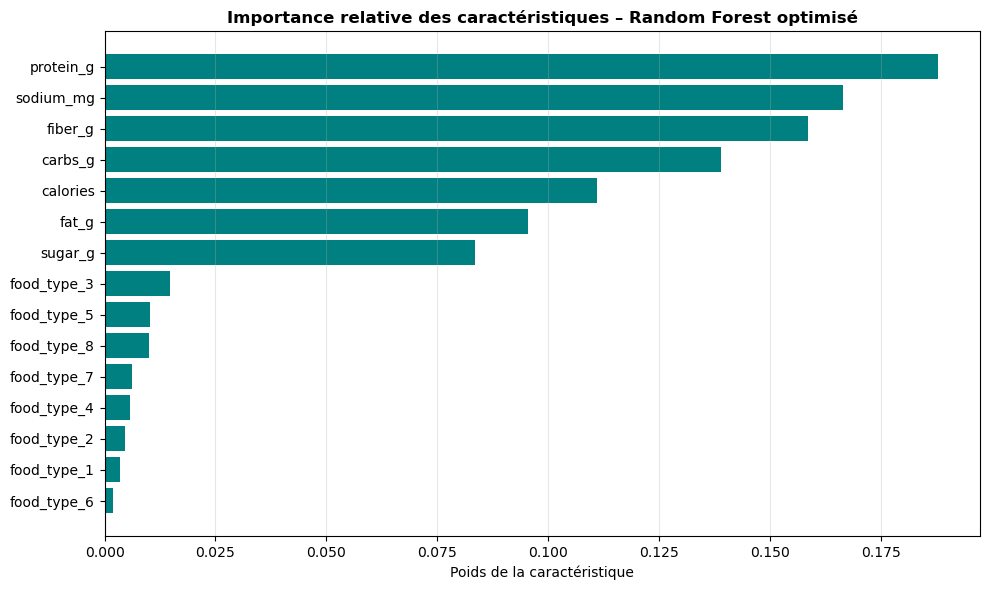

In [143]:
best_model_opt = grid_search.best_estimator_

if hasattr(best_model_opt.named_steps['classifier'], 'feature_importances_'):
    # Noms des caractéristiques après transformation textuelle
    encodeur = best_model_opt.named_steps['preprocessing'].named_transformers_['cat'].named_steps['encoder']
    noms_categories = encodeur.get_feature_names_out(colonnes_textuelles).tolist()
    feature_names = colonnes_numeriques + noms_categories

    importances = best_model_opt.named_steps['classifier'].feature_importances_
    indices = np.argsort(importances)[::-1][:15] # Top 15 pour la lisibilité

    plt.figure(figsize=(10, 6))
    plt.title(f"Importance relative des caractéristiques – {best_model_name} optimisé", fontweight='bold')
    plt.barh(range(len(indices)), importances[indices], align='center', color='teal')
    plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
    plt.xlabel('Poids de la caractéristique')
    plt.gca().invert_yaxis()
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Le modèle sélectionné ne fournit pas d'importance des caractéristiques.")

## 6.3 Comparaison avant / après optimisation

Nous comparons les performances du modèle par défaut et du modèle optimisé sur l'ensemble de test afin de mesurer le gain apporté par le GridSearchCV.

In [144]:
y_pred_default = pipelines[best_model_name].predict(X_test)
y_pred_opti = grid_search.best_estimator_.predict(X_test)

f1_default = f1_score(y_test, y_pred_default, average='macro')
f1_opti = f1_score(y_test, y_pred_opti, average='macro')
acc_default = accuracy_score(y_test, y_pred_default)
acc_opti = accuracy_score(y_test, y_pred_opti)

comparaison = pd.DataFrame({
    'Version': [f'{best_model_name} (défaut)', f'{best_model_name} (optimisé)'],
    'Accuracy': [acc_default, acc_opti],
    'F1-Score (macro)': [f1_default, f1_opti]
})

display(comparaison.round(4))

,Version,Accuracy,F1-Score (macro)
0,Random Forest (défaut),0.9219,0.5705
1,Random Forest (optimisé),0.9219,0.5771


## 6.4 Analyse et interprétation des résultats

**1. Choix du meilleur modèle :**
D'après le tableau comparatif des métriques, le **Random Forest** s'impose comme le modèle le plus performant. Sa structure ensembliste (Bagging) et sa capacité native à modéliser les relations non linéaires et les interactions complexes entre les nutriments expliquent cette supériorité face aux modèles linéaires.

**2. Justification des choix méthodologiques :**
* **Métrique Macro-average :** Sélectionnée rigoureusement car nos classes sont déséquilibrées. Cette métrique accorde un poids strictement équivalent à chaque classe, pénalisant les algorithmes qui ignoreraient les classes minoritaires.
* **Partitionnement strict (Même split) :** L'intégralité des modèles est comparée sur une base de test identique (`random_state=42`), garantissant une comparaison scientifique juste et non biaisée.
* **Préprocesseur unique :** Les transformations (imputation, encodage) sont unifiées, nous comparons ainsi exclusivement la puissance intrinsèque des algorithmes.

**3. Analyse diagnostique des erreurs :**
L'observation des matrices de confusion confirme la pertinence clinique du modèle : les erreurs se concentrent massivement sur des **classes adjacentes** (ex: hésitation entre un score de 60 et 65). Le modèle a assimilé la logique continue du score de santé. Les classes minoritaires (70, 75) accusent un léger déficit prédictif explicable par leur faible représentativité dans le jeu de données initial.

**4. Impact de l'optimisation (GridSearch) :**
La phase d'optimisation n'apporte qu'un gain marginal par rapport à la configuration native. Cela démontre techniquement que les hyperparamètres par défaut de `scikit-learn` permettaient déjà à l'algorithme d'extraire la quasi-totalité de la variance explicative disponible.

**Conclusion :**
Le projet valide le **Random Forest** comme moteur de classification optimal pour prédire le niveau de santé des aliments, en s'appuyant logiquement sur des variables telles que les calories, les sucres ou les graisses. Une piste d'amélioration future consisterait à appliquer des techniques de sur-échantillonnage (type SMOTE) pour compenser le déséquilibre des classes minoritaires.

***Projet accompli avec succès.***